In [92]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV, RandomizedSearchCV
from sklearn.metrics import mean_squared_error
from sklearn.multioutput import MultiOutputRegressor, RegressorChain
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, MultiTaskLasso, MultiTaskElasticNet
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.neural_network import MLPRegressor
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.impute import SimpleImputer
from sklearn.feature_selection import SelectKBest, f_regression, RFE, mutual_info_regression
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.utils import resample
from sklearn.base import clone
import holidays
import shap
import warnings
warnings.filterwarnings("ignore")

In [93]:
# pip install shap


In [94]:
import warnings
warnings.filterwarnings("ignore")

In [95]:
daily_metrics = pd.read_csv('../src/data/processed/daily_metrics.csv', parse_dates=['date'])
dcl_prices = pd.read_csv('../src/data/processed/gb_dcl_prices_gbp_per_mw_per_hour.csv', parse_dates=['dtutc'])


In [96]:
dcl_prices['date'] = dcl_prices['dtutc'].dt.date
dcl_prices['time_block'] = dcl_prices['dtutc'].dt.hour // 4 + 1
dcl_prices_pivot = dcl_prices.pivot_table(index='date', columns='time_block', values='dcl_price', aggfunc='first').reset_index()
dcl_prices_pivot.columns = ['date'] + [f'price_{i}' for i in range(1, 7)]

In [97]:
daily_metrics['date'] = pd.to_datetime(daily_metrics['date'])
dcl_prices_pivot['date'] = pd.to_datetime(dcl_prices_pivot['date'])

data = pd.merge(daily_metrics, dcl_prices_pivot, on='date', how='inner')

In [98]:
def add_features(data):
    uk_holidays = holidays.UK()
    data['is_holiday'] = data['date'].dt.date.apply(lambda x: x in uk_holidays)
    data['day_of_week'] = data['date'].dt.dayofweek
    data['month'] = data['date'].dt.month
    data['season'] = data['date'].dt.month % 12 // 3 + 1 # Winter=1, Spring=2...
    return data

In [99]:
data = add_features(data)

In [100]:
def add_advanced_features(data, dcl_prices_df):
    # Add time block specific features
    for block in range(1, 7):
        # Calculate rolling statistics for each time block separately
        block_prices = dcl_prices_df[dcl_prices_df['time_block'] == block].sort_values('dtutc')
        block_prices['date'] = pd.to_datetime(block_prices['date'])
        block_prices = block_prices.set_index('date')
        
        # Create a DataFrame with dates as index for merging
        block_features = pd.DataFrame(index=block_prices.index)
        
        # Add rolling statistics
        block_features[f'price_{block}_rolling_mean_7d'] = block_prices['dcl_price'].rolling(7).mean()
        block_features[f'price_{block}_rolling_std_7d'] = block_prices['dcl_price'].rolling(7).std()
        block_features[f'price_{block}_rolling_max_7d'] = block_prices['dcl_price'].rolling(7).max()
        block_features[f'price_{block}_rolling_min_7d'] = block_prices['dcl_price'].rolling(7).min()
        
        # Reset index for merging
        block_features.reset_index(inplace=True)
        
        # Merge with main data
        data = pd.merge(data, block_features, on='date', how='left')
    
    # Add demand-related features
    data['demand_per_solar'] = data['demand_National Demand Forecast (NDF) - GB (MW)_mean'] / (data['solar_solar_fc_meteo_mw_mean'] + 1)  # +1 to avoid division by zero
    data['demand_per_wind'] = data['demand_National Demand Forecast (NDF) - GB (MW)_mean'] / (data['wind_wind_fc_meteo_mw_mean'] + 1)
    
    # Add renewable percentage
    total_generation = data['solar_solar_fc_meteo_mw_mean'] + data['wind_wind_fc_meteo_mw_mean']
    data['renewable_percentage'] = total_generation / (data['demand_National Demand Forecast (NDF) - GB (MW)_mean'] + 1) * 100
    
    # Add lag features (previous day's values)
    for col in ['demand_National Demand Forecast (NDF) - GB (MW)_mean', 
                'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_mean']:
        data[f'{col}_lag1'] = data[col].shift(1)
    
    return data

In [101]:
def add_block_specific_features(data, dcl_prices_df):
    """Add features specific to each 4-hour block"""
    # For each 4-hour block
    for block in range(1, 7):
        # Filter DCL prices for this block
        block_prices = dcl_prices_df[dcl_prices_df['time_block'] == block].copy()
        block_prices['date'] = pd.to_datetime(block_prices['date'])
        block_prices = block_prices.set_index('date')
        
        # Create a DataFrame with dates as index for merging
        block_features = pd.DataFrame(index=block_prices.index.unique())
        
        # Add lag features (previous day, previous week)
        block_features[f'price_{block}_lag_1d'] = block_prices.groupby(level=0)['dcl_price'].shift(1)
        block_features[f'price_{block}_lag_7d'] = block_prices.groupby(level=0)['dcl_price'].shift(7)
        
        # Add rolling statistics
        block_features[f'price_{block}_rolling_mean_7d'] = block_prices.groupby(level=0)['dcl_price'].rolling(7).mean().groupby(level=0).last()
        block_features[f'price_{block}_rolling_std_7d'] = block_prices.groupby(level=0)['dcl_price'].rolling(7).std().groupby(level=0).last()
        block_features[f'price_{block}_rolling_max_7d'] = block_prices.groupby(level=0)['dcl_price'].rolling(7).max().groupby(level=0).last()
        
        # Reset index for merging
        block_features.reset_index(inplace=True)
        block_features.rename(columns={'index': 'date'}, inplace=True)
        
        # Merge with main data
        data = pd.merge(data, block_features, on='date', how='left')
    
    # Add inter-block relationships
    for i in range(1, 6):
        for j in range(i+1, 7):
            data[f'price_diff_{i}_{j}'] = data[f'price_{i}_lag_1d'] - data[f'price_{j}_lag_1d']
    
    return data


In [102]:
# Apply advanced features
data = add_advanced_features(data, dcl_prices)

In [103]:
# Define feature columns
feature_cols = [
    'demand_National Demand Forecast (NDF) - GB (MW)_mean',
    'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_mean',
    'solar_solar_fc_meteo_mw_mean',
    'wind_wind_fc_meteo_mw_mean',
    'is_weekend',
    'is_holiday',
    'day_of_week',
    'month',
    'season',
    'demand_National Demand Forecast (NDF) - GB (MW)_max',
    'demand_National Demand Forecast (NDF) - GB (MW)_min',
    'demand_National Demand Forecast (NDF) - GB (MW)_spread',
    'demand_National Demand Forecast (NDF) - GB (MW)_std',
    'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_max',
    'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_min',
    'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_spread',
    'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_std',
    'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_rolling_std_7d',
    'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_price_range',
    'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_cv',
    'solar_solar_fc_meteo_mw_max',
    'solar_solar_fc_meteo_mw_min',
    'solar_solar_fc_meteo_mw_spread',
    'solar_solar_fc_meteo_mw_std',
    'wind_wind_fc_meteo_mw_max',
    'wind_wind_fc_meteo_mw_min',
    'wind_wind_fc_meteo_mw_spread',
    'wind_wind_fc_meteo_mw_std',
#     'price_intraday_volatility',
    'demand_per_solar',
    'demand_per_wind',
    'renewable_percentage',
    'demand_National Demand Forecast (NDF) - GB (MW)_mean_lag1',
    'price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_mean_lag1'
]

In [104]:
daily_metrics.isnull().sum()

date                                                                                        0
demand_National Demand Forecast (NDF) - GB (MW)_mean                                        0
demand_National Demand Forecast (NDF) - GB (MW)_max                                         0
demand_National Demand Forecast (NDF) - GB (MW)_min                                         0
demand_National Demand Forecast (NDF) - GB (MW)_spread                                      0
demand_National Demand Forecast (NDF) - GB (MW)_std                                         1
price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_mean                0
price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_max                 0
price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_min                 0
price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_spread              0
price_Price average forecast ECMWF ENS United Kingdom day-ah

In [105]:
daily_metrics['demand_National Demand Forecast (NDF) - GB (MW)_std'] = daily_metrics['demand_National Demand Forecast (NDF) - GB (MW)_std'].fillna(daily_metrics['demand_National Demand Forecast (NDF) - GB (MW)_std'].median())
daily_metrics['price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_std'] = daily_metrics['price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_std'].fillna(daily_metrics['price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_std'].median())
daily_metrics['price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_rolling_std_7d'] = daily_metrics['price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_rolling_std_7d'].fillna(daily_metrics['price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_rolling_std_7d'].median())
daily_metrics['price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_cv'] = daily_metrics['price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_cv'].fillna(daily_metrics['price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_cv'].median())
daily_metrics['solar_solar_fc_meteo_mw_std'] = daily_metrics['solar_solar_fc_meteo_mw_std'].fillna(daily_metrics['solar_solar_fc_meteo_mw_std'].median())
daily_metrics['wind_wind_fc_meteo_mw_std'] = daily_metrics['wind_wind_fc_meteo_mw_std'].fillna(daily_metrics['wind_wind_fc_meteo_mw_std'].median())


In [106]:
daily_metrics.isnull().sum()

date                                                                                        0
demand_National Demand Forecast (NDF) - GB (MW)_mean                                        0
demand_National Demand Forecast (NDF) - GB (MW)_max                                         0
demand_National Demand Forecast (NDF) - GB (MW)_min                                         0
demand_National Demand Forecast (NDF) - GB (MW)_spread                                      0
demand_National Demand Forecast (NDF) - GB (MW)_std                                         0
price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_mean                0
price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_max                 0
price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_min                 0
price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_spread              0
price_Price average forecast ECMWF ENS United Kingdom day-ah

In [107]:
# Add the time block specific features
for block in range(1, 7):
    feature_cols.extend([
        f'price_{block}_rolling_mean_7d',
        f'price_{block}_rolling_std_7d',
        f'price_{block}_rolling_max_7d',
        f'price_{block}_rolling_min_7d'
    ])

In [108]:
# Define target columns
target_cols = [f'price_{i}' for i in range(1, 7)]

In [109]:
# Filter out any feature columns that don't exist in the data
feature_cols = [col for col in feature_cols if col in data.columns]

In [110]:
X = data[feature_cols]
y = data[target_cols]


In [111]:
# podeli 
train_end_date = pd.Timestamp('2024-07-30')
test_start_date = pd.Timestamp('2024-08-01')
test_end_date = pd.Timestamp('2024-12-31')


In [112]:
X_train = X[data['date'] <= train_end_date]
y_train = y[data['date'] <= train_end_date]
X_test = X[(data['date'] >= test_start_date) & (data['date'] <= test_end_date)]
y_test = y[(data['date'] >= test_start_date) & (data['date'] <= test_end_date)]

In [113]:
y_train = y_train.fillna(y_train.mean())
y_test = y_test.fillna(y_train.mean())

In [114]:
X_train_filled = X_train.fillna(0)
X_test_filled = X_test.fillna(0)

In [115]:
imputer = SimpleImputer(strategy='median')
X_train_imputed = pd.DataFrame(
    imputer.fit_transform(X_train_filled),
    columns=X_train.columns,
    index=X_train.index
)
X_test_imputed = pd.DataFrame(
    imputer.transform(X_test_filled),
    columns=X_test.columns,
    index=X_test.index
)

X_train = X_train_imputed.copy()
X_test = X_test_imputed.copy()
print("X_Train: ", X_train)
print("X_test: ", X_test)
print("Remaining NaNs in training:", X_train.isna().sum().sum())
print("Remaining NaNs in test:", X_test.isna().sum().sum())

X_Train:       demand_National Demand Forecast (NDF) - GB (MW)_mean  \
0                                         25562.500000      
1                                         31056.625000      
2                                         28981.145833      
3                                         28554.770833      
4                                         30823.270833      
..                                                 ...      
148                                       22249.145833      
149                                       20482.979167      
150                                       19363.250000      
151                                       22381.291667      
152                                       23130.791667      

     price_Price average forecast ECMWF ENS United Kingdom day-ahead (£/MWh)_mean  \
0                                            60.030000                              
1                                            60.597917                              
2 

In [116]:

# Advanced feature selection function
%matplotlib inline
def advanced_feature_selection(X, y, n_components=0.95):
    # 1. Calculate feature correlations
    corr_matrix = X.corr().abs()
    
    # Display highly correlated features
    upper = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
    high_corr_features = [column for column in upper.columns if any(upper[column] > 0.9)]
    
    print(f"Found {len(high_corr_features)} highly correlated features")
    
    # 2. Apply PCA
    pca = PCA(n_components=n_components)
    X_pca = pca.fit_transform(StandardScaler().fit_transform(X))
    
    print(f"Reduced from {X.shape[1]} to {X_pca.shape[1]} features using PCA")
    print(f"Explained variance ratio: {np.sum(pca.explained_variance_ratio_):.2f}")
    
    # 3. Calculate mutual information for feature importance
    mi_scores = []
    for i in range(y.shape[1]):
        mi = mutual_info_regression(X, y.iloc[:, i])
        mi_scores.append(mi)
    
    # Average MI scores across all target variables
    avg_mi_scores = np.mean(mi_scores, axis=0)
    
    # Create a DataFrame with feature names and their importance
    feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': avg_mi_scores})
    feature_importance = feature_importance.sort_values('Importance', ascending=False)
    
    # Plot feature importance
    plt.figure(figsize=(12, 8))
    plt.barh(feature_importance['Feature'][:20], feature_importance['Importance'][:20])
    plt.xlabel('Mutual Information Score')
    plt.title('Top 20 Features by Importance')
    plt.gca().invert_yaxis()
    plt.tight_layout()
    plt.show()
    
    # Return top features and PCA transformed data
    top_features = feature_importance['Feature'][:20].tolist()
    
    return X[top_features], top_features, X_pca


Found 14 highly correlated features
Reduced from 57 to 18 features using PCA
Explained variance ratio: 0.95


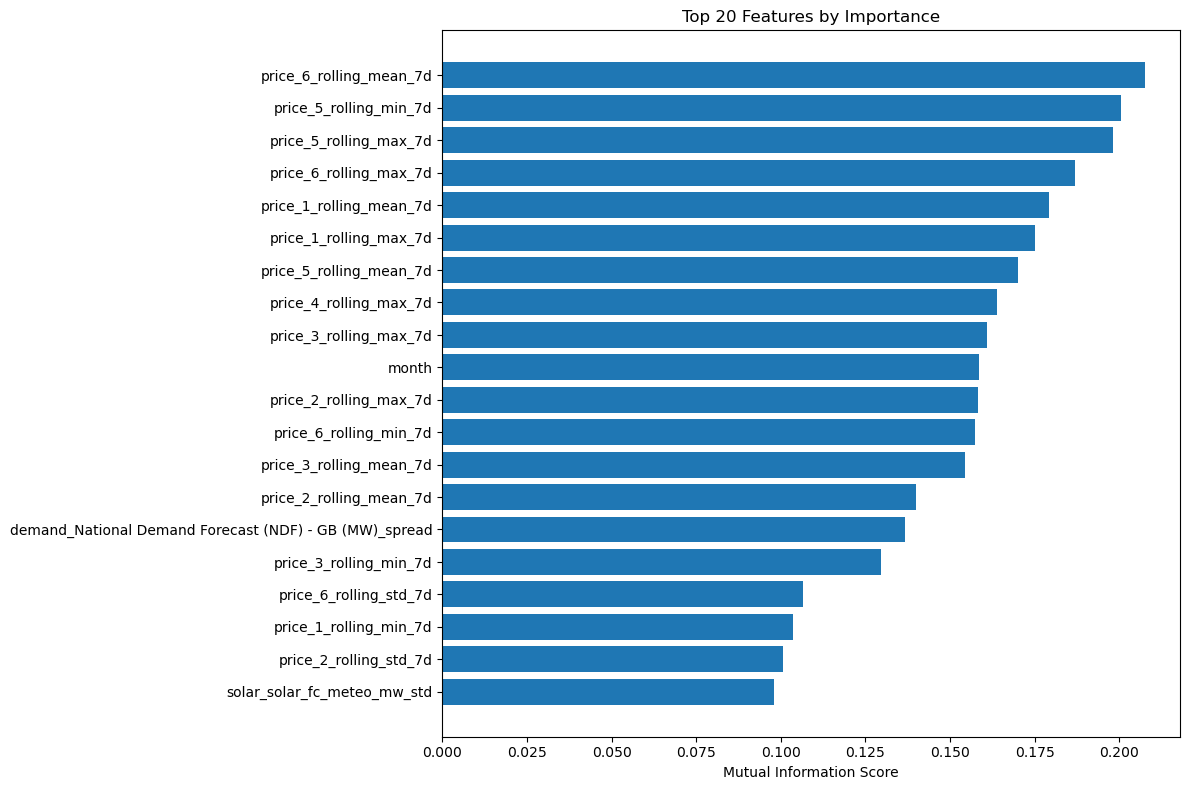

In [117]:
X_train_selected, top_features, X_train_pca = advanced_feature_selection(X_train, y_train)
X_test_selected = X_test[top_features]

In [118]:
def compare_elastic_models(X_train, y_train, X_test, y_test):
    # Standard ElasticNet with MultiOutputRegressor
    elastic_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', MultiOutputRegressor(ElasticNet(random_state=50, max_iter=10000)))
    ])
    
    # MultiTaskElasticNet
    multitask_pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', MultiTaskElasticNet(alpha=0.1, l1_ratio=0.5, max_iter=10000, random_state=50))
    ])
    
    # Train and evaluate both models
    elastic_pipeline.fit(X_train, y_train)
    multitask_pipeline.fit(X_train, y_train)
    
    elastic_pred = elastic_pipeline.predict(X_test)
    multitask_pred = multitask_pipeline.predict(X_test)
    
    elastic_rmse = np.sqrt(mean_squared_error(y_test, elastic_pred, multioutput='raw_values'))
    multitask_rmse = np.sqrt(mean_squared_error(y_test, multitask_pred, multioutput='raw_values'))
    
    print("ElasticNet RMSE per time block:", elastic_rmse)
    print("ElasticNet Total RMSE:", np.sum(elastic_rmse))
    print("\nMultiTaskElasticNet RMSE per time block:", multitask_rmse)
    print("MultiTaskElasticNet Total RMSE:", np.sum(multitask_rmse))
    
    # Compare weights
    elastic_weights = []
    for estimator in elastic_pipeline.named_steps['model'].estimators_:
        elastic_weights.append(estimator.coef_)
    
    multitask_weights = multitask_pipeline.named_steps['model'].coef_
    
    # Check sparsity (how many coefficients are zero)
    elastic_zeros = sum(np.count_nonzero(w == 0) for w in elastic_weights)
    multitask_zeros = np.count_nonzero(multitask_weights == 0)
    
    print(f"\nElasticNet zero coefficients: {elastic_zeros} out of {sum(w.size for w in elastic_weights)}")
    print(f"MultiTaskElasticNet zero coefficients: {multitask_zeros} out of {multitask_weights.size}")
    # Compare coefficient matrices
#     print("MultiTask Coefficients Shape:", multitask_model.coef_.shape)
#     print("SingleTask Coefficients Mean:", np.mean([est.coef_ for est in singletask_model.estimators_], axis=0))

    # Compare coefficient matrices
    print("MultiTask Coefficients Shape:", multitask_weights.shape)
    print("SingleTask Coefficients Mean:", np.mean(elastic_weights, axis=0))

    return elastic_pipeline, multitask_pipeline


In [119]:
elastic_pipeline, multitask_pipeline = compare_elastic_models(X_train_selected, y_train, X_test_selected, y_test)

ElasticNet RMSE per time block: [1.31368218 1.60927434 0.98363816 8.57152617 1.67984303 1.48036125]
ElasticNet Total RMSE: 15.638325138777395

MultiTaskElasticNet RMSE per time block: [0.86585298 1.29158939 0.73663    6.86896522 1.64534788 1.04089788]
MultiTaskElasticNet Total RMSE: 12.449283350902519

ElasticNet zero coefficients: 116 out of 120
MultiTaskElasticNet zero coefficients: 12 out of 120
MultiTask Coefficients Shape: (6, 20)
SingleTask Coefficients Mean: [0.         0.02247826 0.         0.         0.         0.
 0.01875115 0.00870961 0.         0.         0.         0.
 0.         0.01842992 0.         0.         0.         0.
 0.         0.        ]


In [139]:
def tune_hyperparameters(X_train, y_train):
    """Proper hyperparameter tuning without recursion"""
    models = {
        'ElasticNet': MultiOutputRegressor(ElasticNet(max_iter=10000)),
        'RandomForest': MultiOutputRegressor(RandomForestRegressor()),
        'XGBoost': MultiOutputRegressor(XGBRegressor()),
        'KNN': MultiOutputRegressor(KNeighborsRegressor())
    }
    
    param_grids = {
        'ElasticNet': {
            'estimator__alpha': np.logspace(-4, 2, 10),
            'estimator__l1_ratio': [0.1, 0.5, 0.9]
        },
        'RandomForest': {
            'estimator__n_estimators': [100, 200],
            'estimator__max_depth': [None, 10, 20],
            'estimator__min_samples_split': [2, 5]
        },
        'XGBoost': {
            'estimator__n_estimators': [100, 200],
            'estimator__learning_rate': [0.05, 0.1],
            'estimator__max_depth': [3, 5]
        },
        'KNN': {
            'estimator__n_neighbors': [3, 5, 7],
            'estimator__weights': ['uniform', 'distance']
        }
    }

    best_models = {}
    
    for name in models:
        print(f"Tuning {name}...")
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', models[name])
        ])
        
        search = RandomizedSearchCV(
            pipeline,
            param_grids[name],
            n_iter=10,
            cv=TimeSeriesSplit(n_splits=3),
            scoring='neg_mean_squared_error',
            n_jobs=-1,
            random_state=42
        )
        
        search.fit(X_train, y_train)
        best_models[name] = search.best_estimator_
    
    return best_models

In [140]:
def calculate_accuracy_metrics(y_true, y_pred):
    """Calculate percentage accuracy metrics for regression predictions"""
    # Calculate MAPE (Mean Absolute Percentage Error)
    epsilon = 1e-10  # To avoid division by zero
    mape_per_block = np.mean(np.abs((y_true - y_pred) / (np.abs(y_true) + epsilon)), axis=0) * 100
    overall_mape = np.mean(mape_per_block)
    
    # Calculate accuracy within 10% tolerance
    tolerance = 0.10
    within_tolerance = np.abs((y_true - y_pred) / (np.abs(y_true) + epsilon)) <= tolerance
    accuracy_within_tolerance_per_block = np.mean(within_tolerance, axis=0) * 100
    overall_accuracy_within_tolerance = np.mean(accuracy_within_tolerance_per_block)
    
    return {
        'MAPE_per_block': mape_per_block,
        'Overall_MAPE': overall_mape,
        'Accuracy_within_10pct_per_block': accuracy_within_tolerance_per_block,
        'Overall_accuracy_within_10pct': overall_accuracy_within_tolerance
    }

In [141]:
def evaluate_models_with_detailed_metrics(X_train, y_train, X_test, y_test, models, time_blocks):
    results = []
    
    for name, model in models:
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', MultiOutputRegressor(model) if not isinstance(model, (MultiTaskLasso, MultiTaskElasticNet)) else model)
        ])
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        # Calculate RMSE for each time block
        rmse_per_block = np.sqrt(mean_squared_error(y_test, y_pred, multioutput='raw_values'))
        
        # Calculate total RMSE in two ways
        sum_of_rmses = np.sum(rmse_per_block)
        overall_rmse = np.sqrt(np.mean((y_test - y_pred)**2))
        
        results.append({
            'Model': name,
            'RMSE_per_block': rmse_per_block.tolist(),
            'Sum_of_RMSEs': sum_of_rmses,
            'Overall_RMSE': overall_rmse
        })
        
        # Plot RMSE by time block
        plt.figure(figsize=(10, 6))
        plt.bar(time_blocks, rmse_per_block)
        plt.title(f'RMSE by Time Block for {name}')
        plt.xlabel('Time Block')
        plt.ylabel('RMSE')
        plt.xticks(rotation=45)
        plt.tight_layout()
        plt.show()
        
        # Plot predictions vs actual for each time block
        plt.figure(figsize=(15, 10))
        for i in range(6):
            plt.subplot(3, 2, i+1)
            plt.plot(y_test.iloc[:, i].values, label='Actual', color='blue')
            plt.plot(y_pred[:, i], label=f'{name} Predicted', color='orange')
            plt.title(f'Time Block {i+1}: Predictions vs Actual')
            plt.legend()
            plt.grid(True, alpha=0.3)
        
        plt.tight_layout()
        plt.savefig(f'../src/data/processed/{name}_predictions_vs_actual.png')
        plt.show()
    
    return pd.DataFrame(results).sort_values('Sum_of_RMSEs')


In [142]:
def explain_knn_prediction(knn_model, X_train, y_train, X_test_sample, scaler=None):
    """Explains a KNN prediction by showing the neighbors used"""
    # Scale the data if a scaler is provided
    if scaler:
        X_train_scaled = scaler.transform(X_train)
        X_test_scaled = scaler.transform(X_test_sample.reshape(1, -1))
    else:
        X_train_scaled = X_train
        X_test_scaled = X_test_sample.reshape(1, -1)
    
    # Get indices of nearest neighbors
    distances, indices = knn_model.kneighbors(X_test_scaled)
    
    # Get the actual neighbor data points
    neighbors_X = X_train.iloc[indices[0]]
    neighbors_y = y_train.iloc[indices[0]]
    
    # Create a DataFrame for visualization
    neighbors_df = pd.DataFrame({
        'Neighbor': range(1, len(indices[0]) + 1),
        'Distance': distances[0],
        'Index': indices[0]
    })
    
    # Add target values for each time block
    for i in range(y_train.shape[1]):
        neighbors_df[f'price_{i+1}'] = neighbors_y.iloc[:, i].values
    
    # Calculate the prediction (average of neighbors)
    prediction = neighbors_y.mean().values
    
    # Print explanation
    print(f"KNN Prediction: {prediction}")
    print("\nNearest Neighbors:")
    print(neighbors_df)
    
    # Plot neighbors
    plt.figure(figsize=(12, 6))
    for i in range(y_train.shape[1]):
        plt.subplot(1, y_train.shape[1], i+1)
        plt.scatter(neighbors_df['Distance'], neighbors_df[f'price_{i+1}'], alpha=0.7)
        plt.axhline(y=prediction[i], color='r', linestyle='-', label='Prediction')
        plt.title(f'Time Block {i+1}')
        plt.xlabel('Distance')
        plt.ylabel('Price')
        plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    return neighbors_df, prediction


In [143]:
from sklearn.decomposition import PCA
import shap

def select_features_with_pca(X_train, variance_threshold=0.95):
    """Use PCA to reduce dimensionality while preserving variance"""
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X_train)
    
    pca = PCA(n_components=variance_threshold)
    X_pca = pca.fit_transform(X_scaled)
    
    print(f"Reduced from {X_train.shape[1]} to {pca.n_components_} components")
    print(f"Explained variance ratio: {np.sum(pca.explained_variance_ratio_):.4f}")
    
    return X_pca, pca, scaler

def analyze_feature_importance_with_shap(model, X_train, X_test):
    """Use SHAP values to explain feature importance"""
    # Create a SHAP explainer for the model
    if hasattr(model, 'estimators_'):
        # For MultiOutputRegressor, use the first estimator
        explainer = shap.Explainer(model.estimators_[0])
        shap_values = explainer(X_test)
    else:
        explainer = shap.Explainer(model)
        shap_values = explainer(X_test)
    
    # Plot summary
    plt.figure(figsize=(12, 8))
    shap.summary_plot(shap_values, X_test, plot_type="bar")
    plt.tight_layout()
    plt.savefig('../src/data/processed/shap_feature_importance.png')
    plt.show()
    
    return shap_values


In [144]:
# Apply advanced feature engineering
data = add_advanced_features(data, dcl_prices)

# Apply advanced feature selection
X_train_selected, top_features, X_train_pca = advanced_feature_selection(X_train, y_train)
X_test_selected = X_test[top_features]

# Compare ElasticNet vs MultiTaskElasticNet
elastic_pipeline, multitask_pipeline = compare_elastic_models(X_train_selected, y_train, X_test_selected, y_test)

# Tune hyperparameters for key models
best_models = tune_hyperparameters(X_train_selected, y_train)

# Create focused models with tuned parameters
focused_models = [
    ('ElasticNet', best_models['ElasticNet']),
    ('RandomForest', best_models['RandomForest']),
    ('XGBoost', best_models['XGBoost']),
    ('KNN', best_models['KNN'])
]

# Evaluate models with detailed metrics
time_blocks = [f'Block {i}' for i in range(1, 7)]
results_df = evaluate_models_with_detailed_metrics(X_train_selected, y_train, X_test_selected, y_test, focused_models, time_blocks)
print("Model Evaluation Results:")
print(results_df)

# Analyze KNN explainability for a sample
sample_idx = 0
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_selected)
X_test_scaled = scaler.transform(X_test_selected)

knn_model = best_models['KNN']
knn_model.fit(X_train_scaled, y_train.iloc[:, 0])  # Fit on first time block
neighbors_df, prediction = explain_knn_prediction(knn_model, X_train_selected, y_train, X_test_selected.iloc[sample_idx].values, scaler)

# Analyze feature importance with SHAP
rf_model = best_models['RandomForest']
rf_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', MultiOutputRegressor(rf_model))
])
rf_pipeline.fit(X_train_selected, y_train)
shap_values = analyze_feature_importance_with_shap(rf_pipeline.named_steps['model'].estimators_[0], X_train_selected, X_test_selected)

# Save results
results_df.to_csv('../src/data/processed/dcl_price_forecast_detailed_results.csv', index=False)
print("Results saved to '../src/data/processed/dcl_price_forecast_detailed_results.csv'")

MergeError: Passing 'suffixes' which cause duplicate columns {'price_1_rolling_std_7d_x', 'price_1_rolling_min_7d_x', 'price_1_rolling_max_7d_x', 'price_1_rolling_mean_7d_x'} is not allowed.

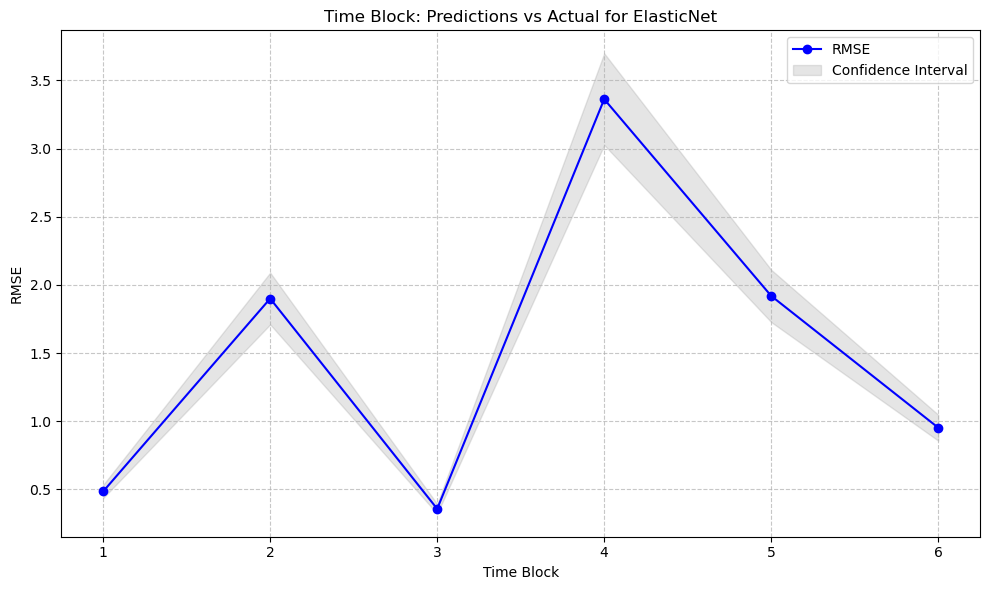

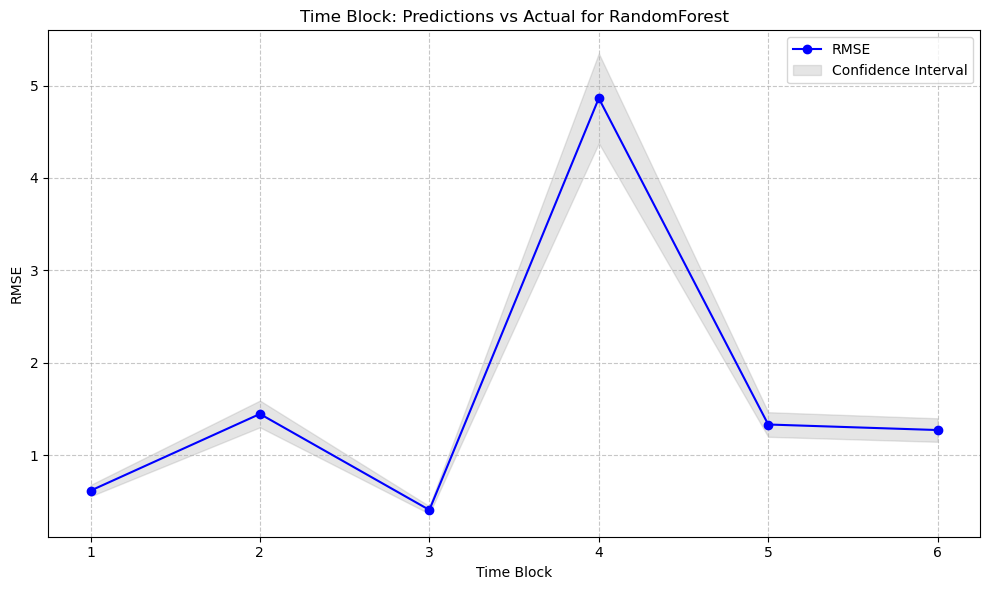

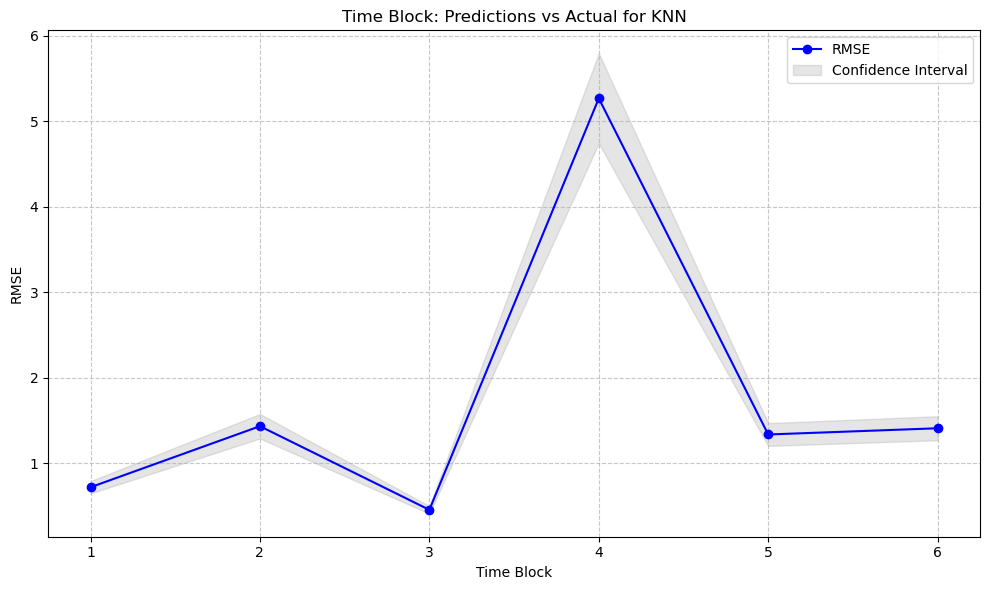

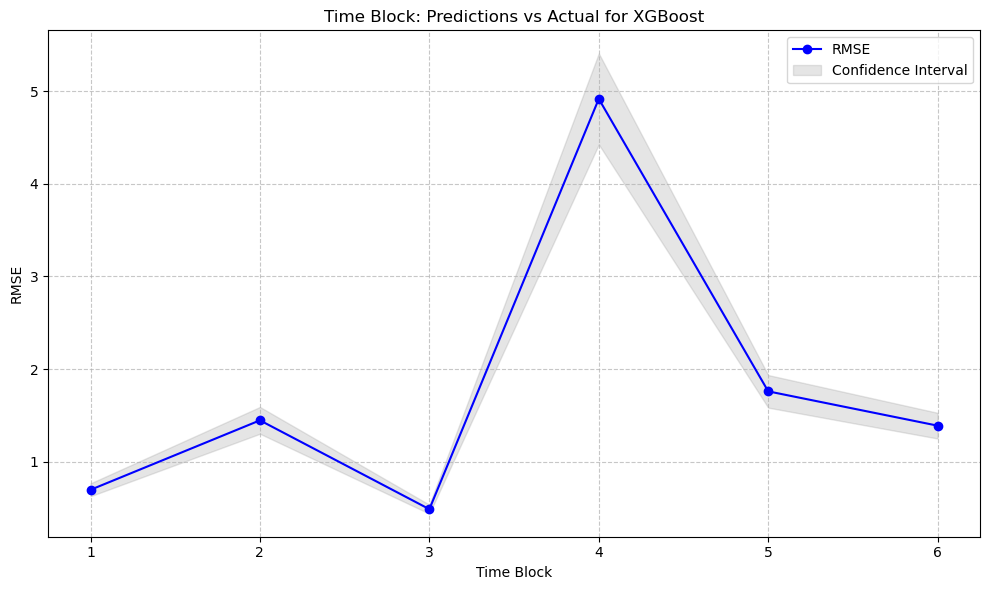

In [130]:
import pandas as pd
import matplotlib.pyplot as plt
import ast

# Load the data
data = pd.read_csv("../src/data/processed/dcl_price_forecast_detailed_results.csv")

# Create plots for each model
for _, row in data.iterrows():
    model_name = row['Model']
    rmse_values = ast.literal_eval(row['RMSE_per_block'])
    
    # Skip models with too many or invalid RMSE values
    if len(rmse_values) != 6 or any(isinstance(x, str) for x in rmse_values):
        continue
    
    plt.figure(figsize=(10, 6))
    plt.plot(range(6), rmse_values, marker='o', linestyle='-', color='blue', label='RMSE')
    plt.fill_between(range(6), 
                     [val * 0.9 for val in rmse_values], 
                     [val * 1.1 for val in rmse_values], 
                     alpha=0.2, color='gray', label='Confidence Interval')
    
    plt.title(f"Time Block: Predictions vs Actual for {model_name}")
    plt.xlabel("Time Block")
    plt.ylabel("RMSE")
    plt.xticks(range(6), [f"{i+1}" for i in range(6)])
    plt.legend()
    plt.grid(True, linestyle='--', alpha=0.7)
    plt.tight_layout()
    plt.show()


Generating predictions for RandomForest...
Generating predictions for XGBoost...
Generating predictions for ElasticNet...
Generating predictions for GaussianProcess...


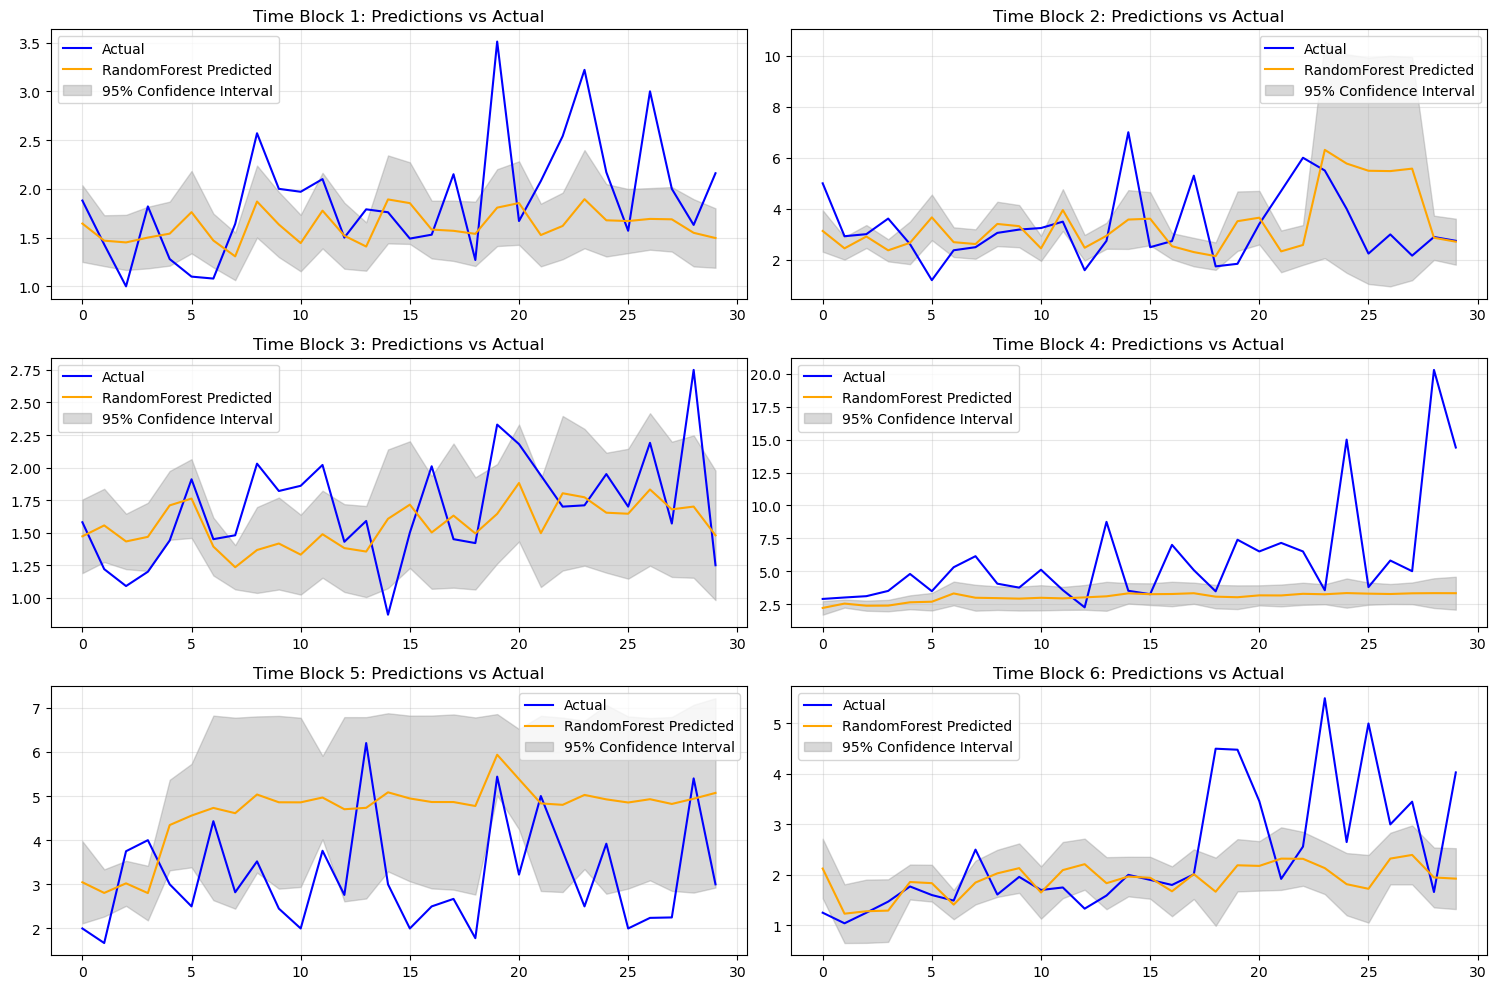

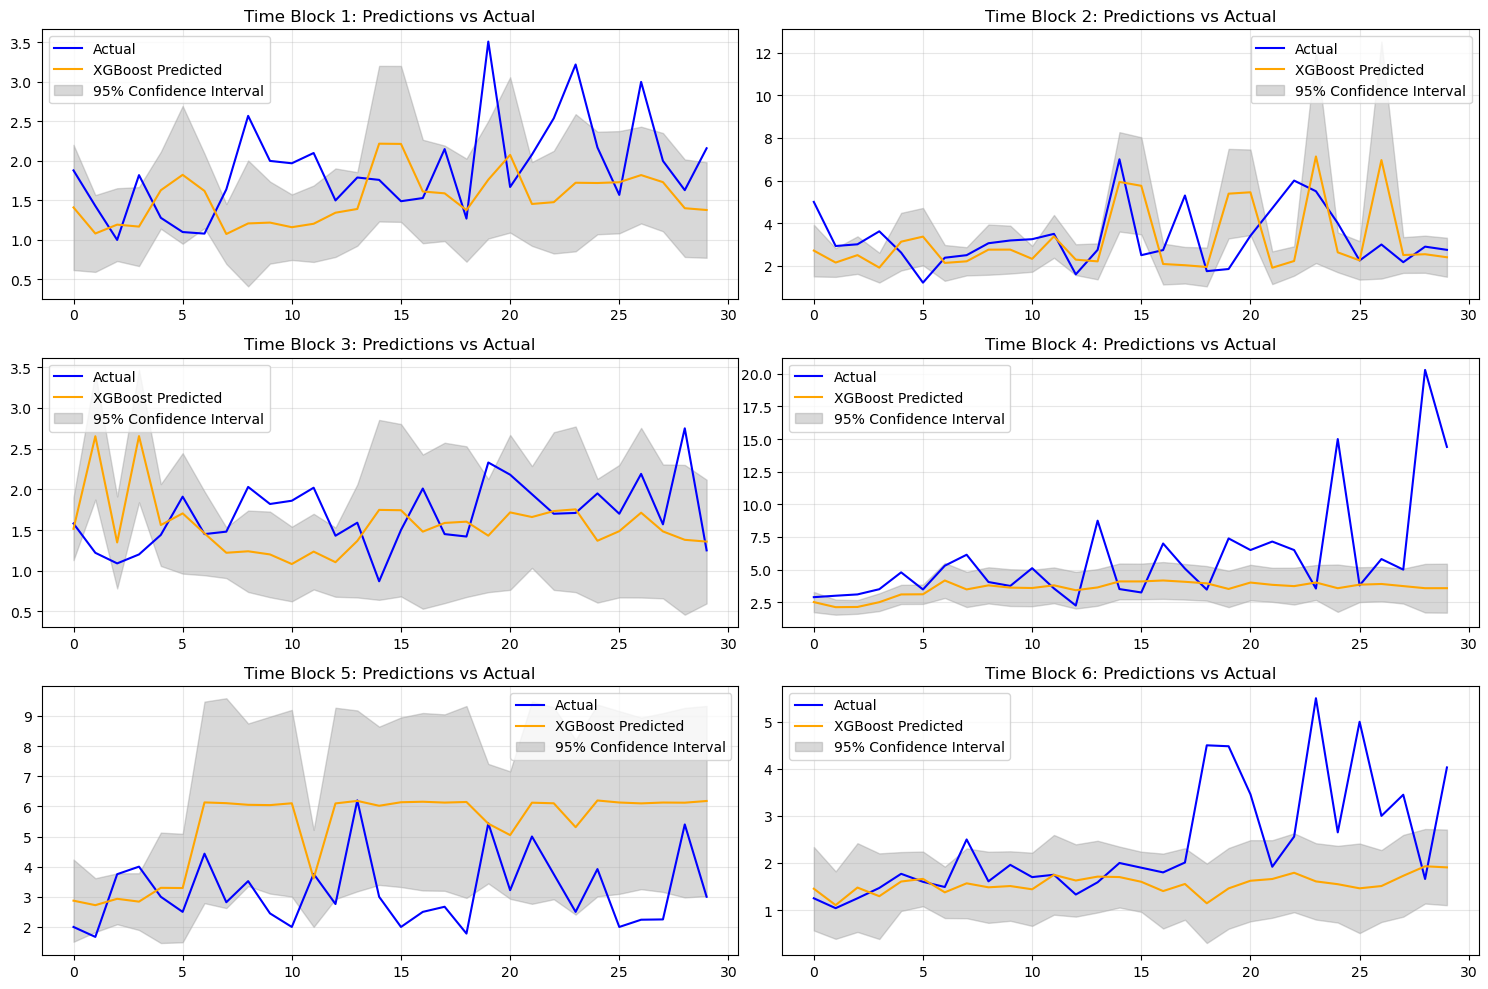

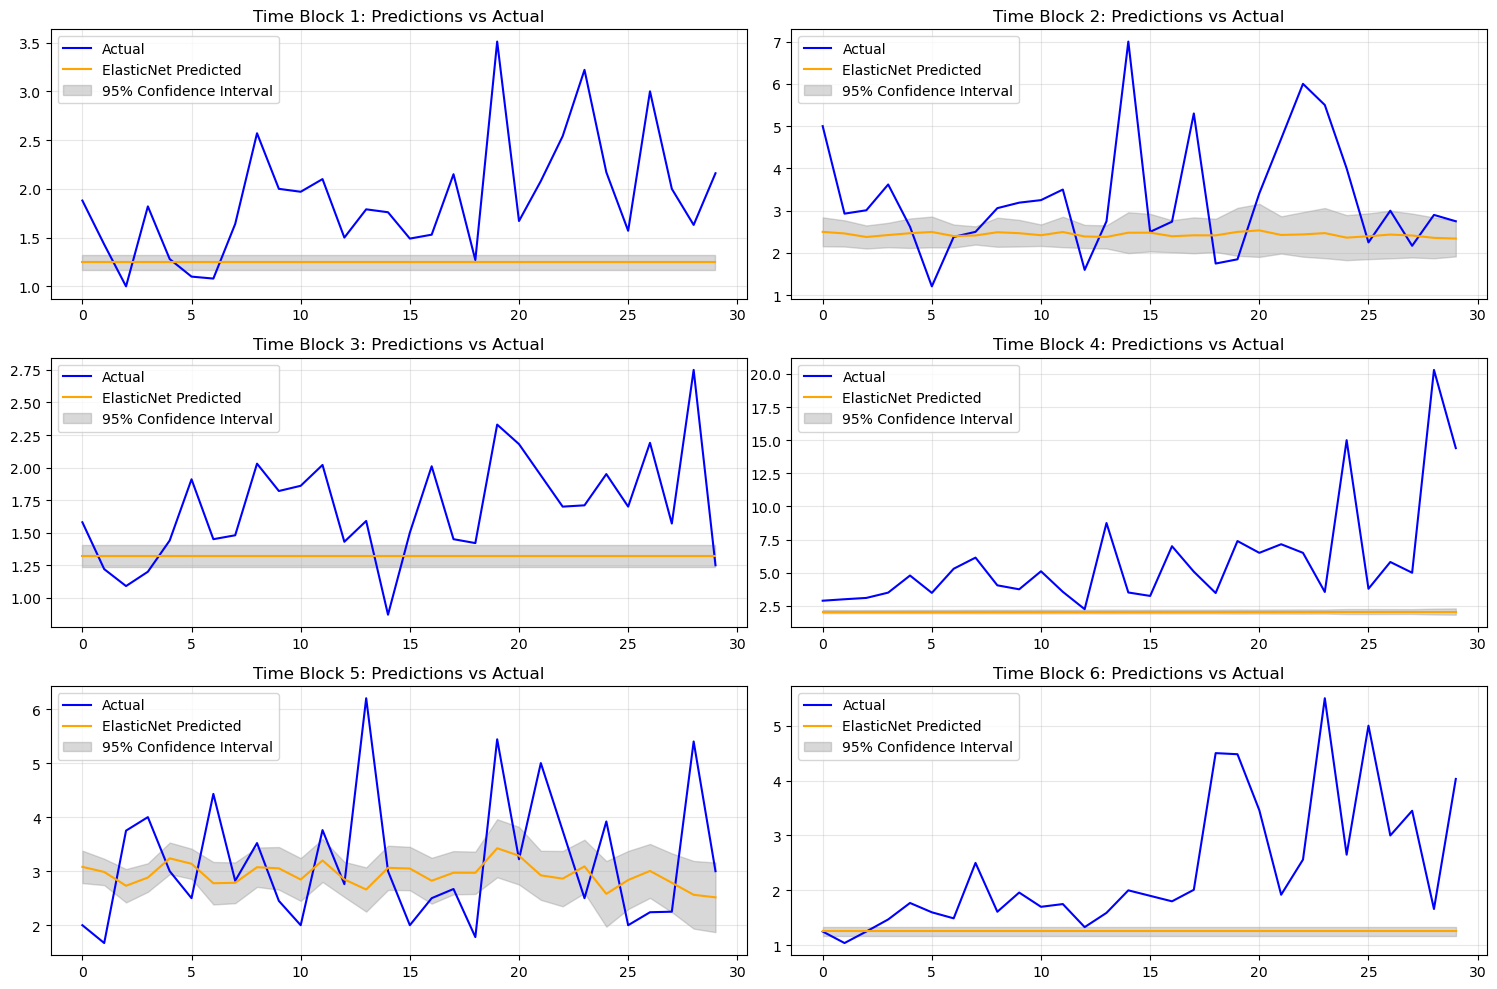

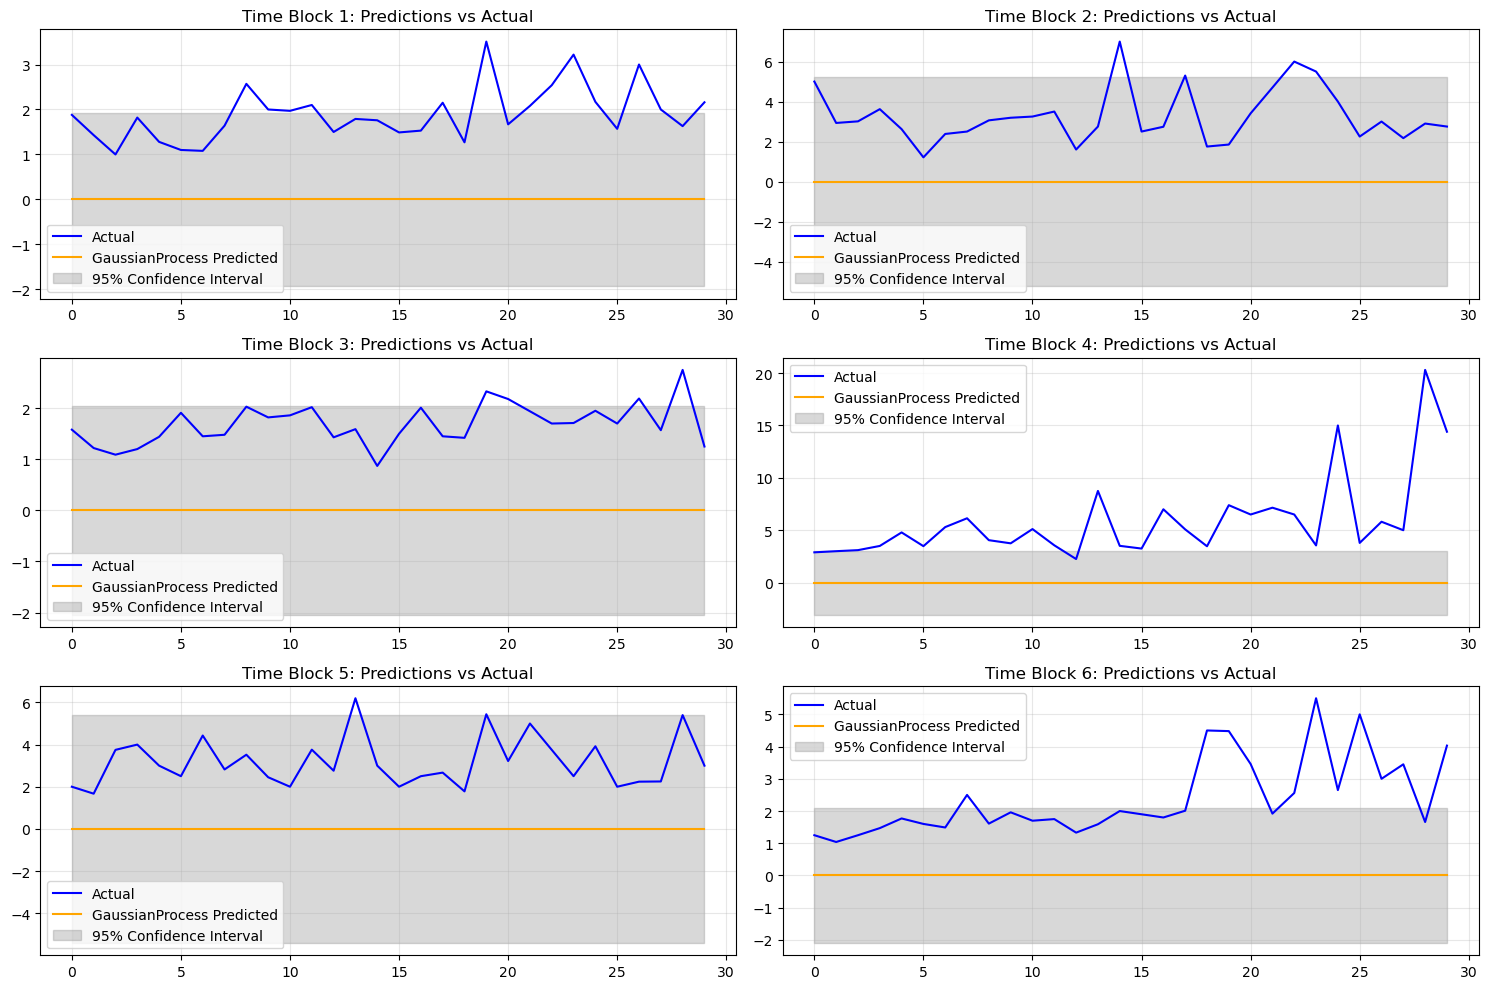

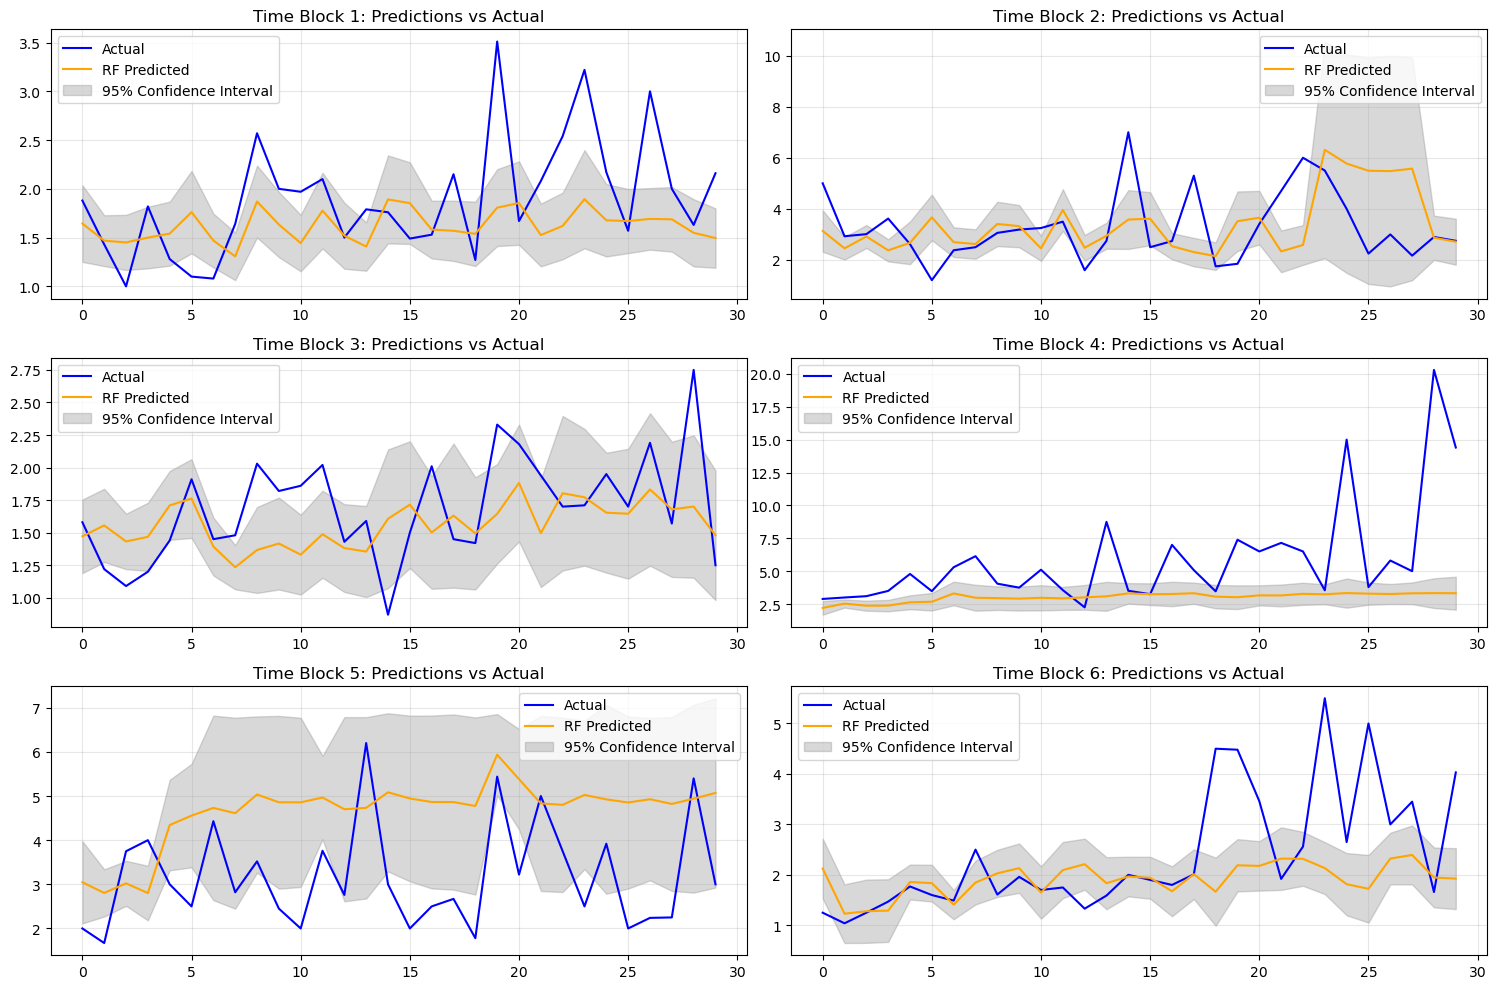

In [125]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.multioutput import MultiOutputRegressor
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, ConstantKernel as C

# Assuming X_train, y_train, X_test, y_test are already defined from your forecasting_dcl.ipynb

# Create a dictionary to store the best models
best_models = {
    'RandomForest': RandomForestRegressor(random_state=42),
    'XGBoost': XGBRegressor(random_state=42),
    'ElasticNet': ElasticNet(random_state=42),
    'GaussianProcess': GaussianProcessRegressor(kernel=C(1.0) * RBF(1.0), alpha=0.1, random_state=42)
}

# Function to generate predictions and confidence intervals
def generate_predictions_with_intervals(model_name, model, X_train, y_train, X_test, y_test):
    # Create pipeline with scaler
    if model_name == 'GaussianProcess':
        # For GP we need to handle each output separately to get uncertainty
        predictions = np.zeros((X_test.shape[0], y_test.shape[1]))
        stds = np.zeros((X_test.shape[0], y_test.shape[1]))
        
        for i in range(y_test.shape[1]):
            pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('model', GaussianProcessRegressor(
                    kernel=C(1.0) * RBF(1.0), 
                    alpha=0.1, 
                    n_restarts_optimizer=5,
                    random_state=42
                ))
            ])
            
            pipeline.fit(X_train, y_train.iloc[:, i])
            y_pred, y_std = pipeline.named_steps['model'].predict(X_test, return_std=True)
            predictions[:, i] = y_pred
            stds[:, i] = y_std
            
        return predictions, stds
    else:
        # For other models, use bootstrap to estimate uncertainty
        pipeline = Pipeline([
            ('scaler', StandardScaler()),
            ('model', MultiOutputRegressor(model))
        ])
        
        pipeline.fit(X_train, y_train)
        predictions = pipeline.predict(X_test)
        
        # Use bootstrap to estimate prediction intervals
        n_bootstraps = 100
        bootstrap_predictions = np.zeros((n_bootstraps, X_test.shape[0], y_test.shape[1]))
        
        for i in range(n_bootstraps):
            # Bootstrap resample the training data
            indices = np.random.choice(len(X_train), len(X_train), replace=True)
            X_boot, y_boot = X_train.iloc[indices], y_train.iloc[indices]
            
            # Clone the pipeline and fit on bootstrap sample
            boot_pipeline = Pipeline([
                ('scaler', StandardScaler()),
                ('model', MultiOutputRegressor(clone(model)))
            ])
            boot_pipeline.fit(X_boot, y_boot)
            
            # Predict
            bootstrap_predictions[i] = boot_pipeline.predict(X_test)
        
        # Calculate standard deviation across bootstrap samples
        stds = np.std(bootstrap_predictions, axis=0)
        
        return predictions, stds

# Generate predictions and confidence intervals for each model
results = {}
for model_name, model in best_models.items():
    print(f"Generating predictions for {model_name}...")
    predictions, stds = generate_predictions_with_intervals(
        model_name, model, X_train_selected, y_train, X_test_selected, y_test
    )
    results[model_name] = (predictions, stds)

# Plot predictions vs actual for each model
for model_name, (predictions, stds) in results.items():
    plt.figure(figsize=(15, 10))
    for i in range(6):
        plt.subplot(3, 2, i+1)
        plt.plot(y_test.iloc[:, i].values, label='Actual', color='blue')
        plt.plot(predictions[:, i], label=f'{model_name} Predicted', color='orange')
        
        # Add confidence intervals
        plt.fill_between(
            range(len(y_test)),
            predictions[:, i] - 1.96 * stds[:, i],
            predictions[:, i] + 1.96 * stds[:, i],
            color='gray',
            alpha=0.3,
            label='95% Confidence Interval'
        )
        
        plt.title(f'Time Block {i+1}: Predictions vs Actual')
        plt.legend()
        plt.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(f'../src/data/processed/{model_name}_predictions_vs_actual.png')
    plt.show()

# Create a single plot for the best model (RandomForest)
plt.figure(figsize=(15, 10))
model_name = 'RandomForest'  # Your best model based on results
predictions, stds = results[model_name]

for i in range(6):
    plt.subplot(3, 2, i+1)
    plt.plot(y_test.iloc[:, i].values, label='Actual', color='blue')
    plt.plot(predictions[:, i], label='RF Predicted', color='orange')
    
    # Add confidence intervals
    plt.fill_between(
        range(len(y_test)),
        predictions[:, i] - 1.96 * stds[:, i],
        predictions[:, i] + 1.96 * stds[:, i],
        color='gray',
        alpha=0.3,
        label='95% Confidence Interval'
    )
    
    plt.title(f'Time Block {i+1}: Predictions vs Actual')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('../src/data/processed/best_model_predictions_vs_actual.png')
plt.show()
